In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
### 기본적인 llm 사용법, -> langChain은 결국 chain으로 연결된 프롬프트 쿼리를 모델에 invoke하는것임.

from langchain_openai import ChatOpenAI

query="인프런에 어떤 강의가 요즘 핫한가요?"

llm = ChatOpenAI(model= 'gpt-4o-mini')
llm.invoke(query)


AIMessage(content="인프런에서 요즘 핫한 강의는 주로 데이터 과학, 인공지능, 웹 개발, 모바일 앱 개발 등과 관련된 주제들이 많습니다. 특히 Python, 머신러닝, 프론트엔드 프레임워크(React, Vue.js 등)와 같은 기술 스택에 대한 강의가 인기가 높습니다. \n\n변화하는 기술 트렌드에 따라 강의의 인기 또한 다를 수 있으니, 인프런의 '실시간 인기 강의' 또는 '추천 강의' 섹션을 확인해보는 것이 좋습니다. 또한 리뷰와 수강생 평가를 참고하면 더욱 도움이 될 것입니다. 어떤 특정 분야에 관심이 있으신가요?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 23, 'total_tokens': 175, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3d805c4100', 'id': 'chatcmpl-E62mBTbn1xUL5Zo4og9HF03uhYXqI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fa0ce-f794-78f3-86de-a0d903e90ee1-0', tool_calls=[], invalid_tool_calls=[], usage

In [ ]:
### 기본적  LangGraph 구성

from email import message
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]



In [4]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)


In [ ]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages':[ai_message]}

In [6]:
graph_builder.add_node('generate',generate)

In [8]:
from langgraph.graph import START, END

graph_builder.add_edge(START,'generate')
graph_builder.add_edge('generate',END)

In [9]:
graph = graph_builder.compile()

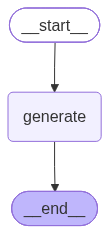

In [10]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
from langchain_core.messages import HumanMessage

query="인프런에 어떤 강의가 요즘 핫한가요?"
initial_state:AgentState = {'messages':[HumanMessage(content= query)]}
graph.invoke(initial_state)

{'messages': [AIMessage(content='인프런에서 요즘 인기 있는 강의는 주로 데이터 사이언스, 인공지능, 웹 개발, 그리고 클라우드 컴퓨팅 관련 강의입니다. 특히 Python을 활용한 데이터 분석, 머신러닝, 딥러닝 강의들이 많은 관심을 받고 있습니다. 또한 프론트엔드와 백엔드 개발 기술을 다룬 강의들도 꾸준히 인기가 있습니다.\n\n정확한 최신 정보는 인프런 웹사이트를 방문하거나 그들의 인기 강의 섹션을 확인해 보시는 것이 좋습니다. 특정한 주제가 궁금하다면 말씀해 주시면 더 자세한 정보를 제공해 드릴 수 있습니다!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 23, 'total_tokens': 165, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3d805c4100', 'id': 'chatcmpl-E66K3pxyUVKH0a272iuT9WqWfe9Gy', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fa19e-f851-77f3-806e-8a88c5ee9ec3-0', tool_calls=[], invalid_tool_calls=[], us